# Cantilever with a GLARE fiber-metal laminate
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/shell/cantilever_fml.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/shell/cantilever_fml.ipynb)

A cantilever plate built from a layered `Shell` and a `Laminate` stacking
sequence: a GLARE 3-3/2-0.3 fiber-metal laminate with three elastoplastic
aluminium 2024-T3 face sheets and two glass-fiber/epoxy (GFRP) 0/90 cross-ply
layers.

The `Laminate` owns the through-thickness integration (one Simpson rule per
layer) and precomputes the transverse shear stiffness and the mass integrals.
The section stiffness is integrated over these stations by the `Shell` during
the analysis, so the metal layers can yield: the laminate mixes elastic and
elastoplastic plies.

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import torch

from torchfem import Laminate, Shell
from torchfem.materials import (
    IsotropicPlasticityPlaneStress,
    OrthotropicElasticityPlaneStress,
)
from torchfem.mesh import rect_tri

torch.set_default_dtype(torch.float64)

## Materials and stacking sequence

In [9]:
# Glass-fiber reinforced polymer ply (S2-glass/epoxy)
gfrp = OrthotropicElasticityPlaneStress(
    E_1=54000.0,
    E_2=9400.0,
    nu_12=0.33,
    G_12=5500.0,
    G_13=5500.0,
    G_23=3000.0,
    rho=1.8e-9,
)

# Aluminium 2024-T3 face sheet: elastoplastic with linear isotropic hardening
sigma_y = 345.0  # yield stress [MPa]
hardening = 700.0  # hardening modulus [MPa]
alu = IsotropicPlasticityPlaneStress(
    E=72000.0,
    nu=0.33,
    sigma_f=lambda q: sigma_y + hardening * q,
    sigma_f_prime=lambda q: hardening,
    rho=2.7e-9,
)

# GLARE 3-3/2-0.3 layup: three 0.3 mm Al sheets and two 0/90 GFRP cross-ply
# layers (0.125 mm per ply), stacked symmetrically about the mid-plane.
layup = Laminate(
    materials=[alu, gfrp, gfrp, alu, gfrp, gfrp, alu],
    thicknesses=[0.3, 0.125, 0.125, 0.3, 0.125, 0.125, 0.3],
    angles=[0.0, 0.0, torch.pi / 2, 0.0, torch.pi / 2, 0.0, 0.0],
)
layup

<torch-fem laminate (7 layers, 21 integration points)>

## Model setup

A rectangular plate clamped at one edge with a transverse tip load large enough
to drive the aluminium face sheets into yield near the clamped root. The deformation is technically beyond small-strain analysis, but for testing the material non-linearity this is fine. 

In [10]:
nodes, elements = rect_tri(10, 5, 100.0, 50.0, variant="zigzag")
nodes = torch.hstack([nodes, torch.zeros((len(nodes), 1))])

plate = Shell(nodes, elements, layup)

# Define masks for boundaries
left = nodes[:, 0] < 0.01
right = nodes[:, 0] > 99.9
front = nodes[:, 1] < 0.01
back = nodes[:, 1] > 49.99
corner_1 = right & front
corner_2 = right & back

# Apply load boundary conditions
plate.constraints[left] = True
plate.forces[corner_1, 2] = -50.0
plate.forces[corner_2, 2] = -50.0

## Solve

The load is applied in increments so the elastoplastic return mapping in the
aluminium layers can follow the loading path.

In [11]:
increments = torch.linspace(0.0, 1.0, 11)
u, f, sigma, _, state = plate.solve(
    increments=increments,
    aggregate_integration_points=False,
    return_intermediate=True,
)

## Visualize results

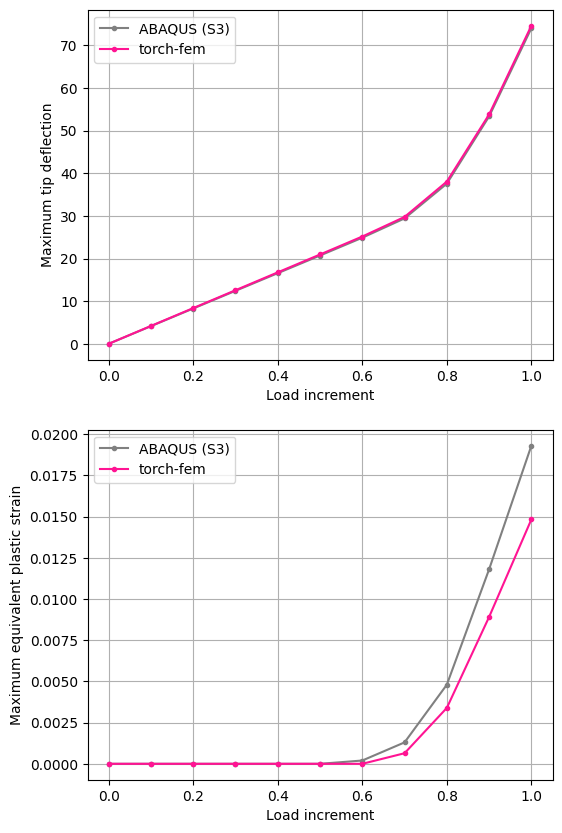

In [12]:
# Maximum tip deflection
u_max = u.abs().max(dim=1).values
u_max_abq = [0.00, 4.14, 8.28, 12.43, 16.57, 20.71, 24.89, 29.42, 37.57, 53.35, 74.05]

# Maximum equivalent plastic strain
peeq_max = state[:, :, 0].max(dim=1).values
peeq_max_abq = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.0013, 0.0048, 0.0118, 0.0193]

# Plot results
fig, ax = plt.subplots(2, 1, figsize=(6, 10))
ax[0].plot(increments, u_max_abq, ".-", color="gray", label="ABAQUS (S3)")
ax[0].plot(increments, u_max[:, 2], ".-", color="deeppink", label="torch-fem")
ax[0].set_xlabel("Load increment")
ax[0].set_ylabel("Maximum tip deflection")
ax[0].grid()
ax[0].legend()
ax[1].plot(increments, peeq_max_abq, ".-", color="gray", label="ABAQUS (S3)")
ax[1].plot(increments, peeq_max, ".-", color="deeppink", label="torch-fem")
ax[1].set_xlabel("Load increment")
ax[1].set_ylabel("Maximum equivalent plastic strain")
ax[1].grid()
ax[1].legend()
plt.show()

## Through-thickness stress profile

With `aggregate_integration_points=False`, `sigma` keeps one entry per
through-thickness station (`n_simpson` per layer, ordered bottom-to-top). Below
we plot the in-plane normal stress over the thickness at the element with the
largest equivalent plastic strain. The aluminium plies cap near the yield
stress, while the GFRP plies carry load elastically.

In [ ]:
# Element with the largest equivalent plastic strain (PEEQ)
peeq = state[-1, :, :, 0].abs()  # [n_z, n_elem]
e = int(peeq.max(dim=0).values.argmax())

# Through-thickness coordinate and in-plane normal stress at that element
z = plate.section.z[:, e]
sxx = sigma[-1, :, e, 0, 0]

# Ply interfaces and the material / fiber orientation of each ply
ply_t = torch.stack([th[e] for th in plate.section.thicknesses])
interfaces = torch.cat([torch.zeros(1), ply_t.cumsum(0)]) - plate.thickness[e] / 2
ply_types = ["Al", "0°", "90°", "Al", "90°", "0°", "Al"]
ply_colors = {"Al": "lightgray", "0°": "lightblue", "90°": "navajowhite"}

fig, ax = plt.subplots(figsize=(4, 5))
# Shade each ply by its material / fiber orientation
for k, ptype in enumerate(ply_types):
    ax.axhspan(interfaces[k].item(), interfaces[k + 1].item(), color=ply_colors[ptype])

# Plot the through-thickness stress distribution
ax.plot(sxx, z, ".-", color="black")
ax.set_xlabel("σ_xx [MPa]")
ax.set_ylabel("z [mm]")
ax.set_title(f"Through-thickness stress (Element {e})")
ax.legend(
    handles=[Patch(color=c, label=t) for t, c in ply_colors.items()],
    loc="lower right",
)
plt.show()